# Diffusion Model — Single Sample Test
**Name:** Saad Ali  **Roll No:** MSDS25066

This notebook loads the trained diffusion model and generates a sample image from pure noise.


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
!pip install torch torchvision pillow matplotlib numpy

In [4]:
import torch
import matplotlib.pyplot as plt
from MSDS25066_05_train import UNet, generate_image, alpha_bars, betas, alphas, T
from MSDS25066_05_test import load_model, save_generated_image

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "saved_models/diffusion_model-200epoch.pth"
model = load_model(model_path, device=device)
print(f"Model loaded from {model_path}, running on {device}")

Model loaded from saved_models/diffusion_model-200epoch.pth, running on cpu


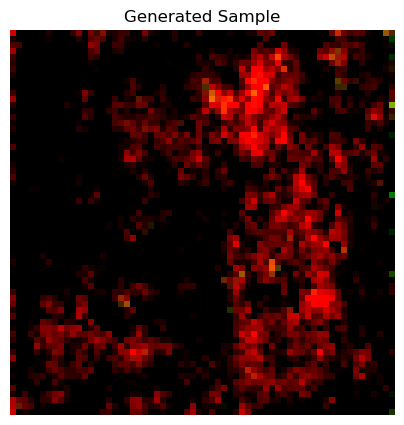

In [6]:
generated = generate_image(model, alpha_bars, betas, alphas, T, device=device)
img = (generated.clamp(-1, 1) + 1) / 2
img = img.squeeze(0).permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Generated Sample")
plt.show()